<div align="center">
    <h3>Aristotle University of Thessaloniki</h3>
    <h1>Analysis of Medical Images MedMNIST with CNN, Transfer Learning & Vision Transformers (Pytorch)</h1>
    <h3>Deep-Learning Winter Sem. 2025-2026</h3>
    <p>
        <b>Zisis Katsaros - 10666</b><br>
        <small>Prof.: P. Petrantonakis</small>
    </p>
</div>

## **0.** Description of Dataset ##

In [8]:
! pip install medmnist
! python &

In [9]:
import medmnist
from medmnist import OrganSMNIST
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

# Define image to tensor transform 
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) 
])

# Setup training, validation, and test datasets
train_dataset = OrganSMNIST(split="train", download=True, transform=data_transform)
val_dataset = OrganSMNIST(split="val", download=True, transform=data_transform)
test_dataset = OrganSMNIST(split="test", download=True, transform=data_transform)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 64
torch.manual_seed(42) 
train_data = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_data = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_data = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Print dataset info:
print(f"==================== Dataset Info ====================")
print(f" - Name: OrganSMNIST")

num_of_classes = len(train_dataset.info['label']) # get number of classes from dataset info
print(f" - Number of classes: {num_of_classes}")

images, labels = next(iter(train_data)) # get first batch of iterator
channels, rows, cols = images.shape[1], images.shape[2], images.shape[3] # get image characteristics
if channels == 1:
    print(f" - Image size: {rows}x{cols} (Grayscale)")
elif channels == 3:
    print(f" - Image size: {rows}x{cols} (RGB)")
else:
    print(f" - Image size: {rows}x{cols}")

# get training, validation, test and total samples
train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
num_samples = train_size + val_size + test_size

print(f" - Samples: {num_samples}")
print(f" - Training: {train_size}")
print(f" - Validation: {val_size}")
print(f" - Test: {test_size}")

==================== Dataset Info ====================
 - Name: OrganSMNIST
 - Number of classes: 11
 - Image size: 28x28 (Grayscale)
 - Samples: 25211
 - Training: 13932
 - Validation: 2452
 - Test: 8827


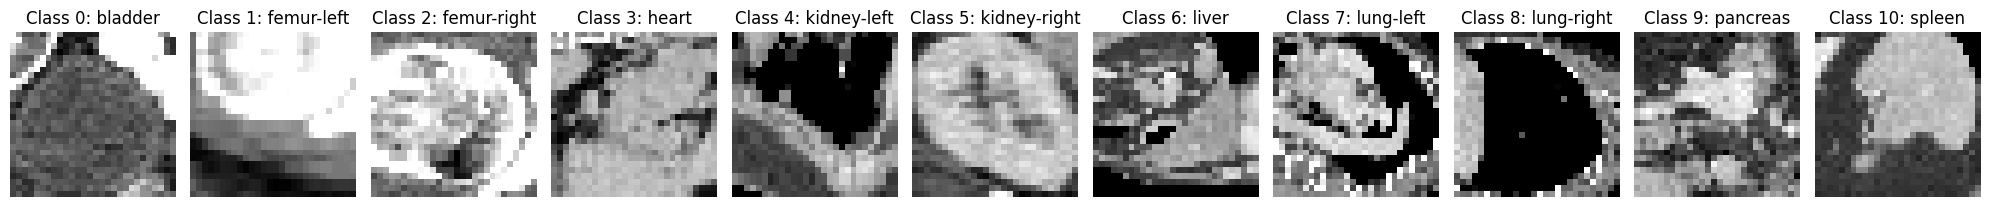

Class Distribution:
 - Class 0 (bladder): 8.24%
 - Class 1 (femur-left): 4.52%
 - Class 2 (femur-right): 4.41%
 - Class 3 (heart): 5.18%
 - Class 4 (kidney-left): 8.13%
 - Class 5 (kidney-right): 8.03%
 - Class 6 (liver): 24.86%
 - Class 7 (lung-left): 5.32%
 - Class 8 (lung-right): 5.76%
 - Class 9 (pancreas): 14.38%
 - Class 10 (spleen): 11.17%


In [10]:
# Visulaization and Class distribution

labels_dict = train_dataset.info['label'] # get lables dictionary from dataset info

fig, axes = plt.subplots(1, num_of_classes, figsize=(20, 3)) # create plot

classes = set()
num_of_samples_per_class = np.zeros(num_of_classes, dtype=int) # initialize samples per class counter 
images_dataset = OrganSMNIST(split="train", download=True, size=28) # load training dataset without transform

# iterate through the dataset
for i in range(len(images_dataset)):
    image, label = images_dataset[i]
    label = label.item()

    # plot each new class sample 
    if label not in classes:
        ax = axes[label]
        ax.imshow(image, cmap='gray')
        ax.set_title(f"Class {label}: {labels_dict[str(label)]}")
        ax.axis('off')

        classes.add(label)

    # count samples per class
    num_of_samples_per_class[label] += 1

# get distribution by dividing by total training samples
class_distribution = num_of_samples_per_class / train_size

plt.tight_layout()
plt.show()

print(f"Class Distribution:")
for i in range(num_of_classes):
    print(f" - Class {i} ({labels_dict[str(i)]}): {class_distribution[i] * 100:.2f}%")

## **1.** CNN from scratch ##

### 1.1 MyCNN: ###

In [11]:
import numpy as np
import torch
from torch import nn

class MyCNN(nn.Module):
    def __init__(self, img_size, num_of_channels, num_of_classes, num_of_filters=32, num_of_blocks=3, batch_norm=False, 
                 layer_norm=False, dropout_prob=0.0):
        super(MyCNN, self).__init__()

        self.blocks = nn.ModuleList() # list to hold convolutional blocks

        in_channels = num_of_channels # initial input channel size = number of image channels
        out_channels = num_of_filters # initial output channel size = number of filters

        # Convolutional Blocks: Conv2d -> (BatchNorm) -> ReLU -> MaxPool2d -> (LayerNorm)
        for i in range(num_of_blocks):
            self.blocks.append(nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels) if batch_norm else nn.Identity(),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
                nn.LayerNorm([out_channels, img_size // (2 ** (i + 1)), img_size // (2 ** (i + 1))]) if layer_norm else nn.Identity()
            ))
            in_channels = out_channels # update input channels for next block
            out_channels *= 2  # double output channels for next block 

            # Calculate final image size 
            final_img_size = img_size // (2 ** num_of_blocks) # halfed for each block due to MaxPool2d

            if final_img_size < 1:
                print(f"Image size too small for the number of blocks.") 

            self.flatten_dim = in_channels * final_img_size ** 2     

            # Fully Connected Layer:
            self.dropout = nn.Dropout(dropout_prob) if dropout_prob > 0 else nn.Identity()
            self.fc1 = nn.Linear(self.flatten_dim, num_of_classes)     

    def forward(self, x):
        for block in self.blocks:
            x = block(x) # pass through each convolutional block

        x = x.flatten(1)

        x = self.dropout(x) 
        x = self.fc1(x)
        return x
            
# Training Loop:
def train_loop(model, dataloader, optimizer, criterion, device):
    model.train() # model in training mode

    total_loss = 0.0
    correct = 0
    total = 0

    # iterate through training batches
    for batch, (images, labels) in enumerate(dataloader):
        images = images.to(device) 
        labels = labels.squeeze().to(device)

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # loss function
        total_loss += loss.item()

        optimizer.zero_grad() # zero the previous gradients
        loss.backward() # backpropagation
        optimizer.step() # update weights

        preds = outputs.argmax(dim=1) # get predicted class
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total # return loss and accuracy

# Test Loop:
def test_loop(model, dataloader, criterion, device):
    model.eval() # model in evaluation mode

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad(): # disable gradient calculation
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images) # forward pass
            loss = criterion(outputs, labels) # loss function
            total_loss += loss.item()

            preds = outputs.argmax(dim=1) # get predicted class
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy()) # store all predictions
            all_labels.extend(labels.cpu().numpy()) # store all true labels

    # return loss, accuracy, all predictions and all true labels
    return total_loss / len(dataloader), correct / total, np.array(all_preds), np.array(all_labels) 


### 1.2 Functions used for Visualization: ###

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# Loss, Accuracy, Confusion Matrix Plot 
def plot_loss_acc_confusion(train_losses, val_losses, train_accuracies, val_accuracies, test_acc,
                          targets, preds, labels_dict, batch_size, learning_rate, num_of_blocks=3, batch_norm=False, layer_norm=False,
                          dropout=0.0, weight_decay=0.0):
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.3)

    # Top-left: Loss curves
    ax_loss = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(train_losses) + 1)
    ax_loss.plot(epochs, train_losses, 'b-', label='Training Loss')
    ax_loss.plot(epochs, val_losses, 'r-', label='Validation Loss')
    ax_loss.set_title('Loss over Epochs')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss')
    ax_loss.grid(True, alpha=0.2)
    ax_loss.legend(loc='best')

    # Top-right: Accuracy curves
    ax_acc = fig.add_subplot(gs[0, 1])
    ax_acc.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    ax_acc.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    ax_acc.set_title('Accuracy over Epochs')
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_ylim(0, 1)
    ax_acc.grid(True, alpha=0.2)
    ax_acc.legend(loc='best')

    # Bottom-left: Confusion Matrix
    ax_cm = fig.add_subplot(gs[1, 0])
    confusion_mat = confusion_matrix(targets, preds)
    im = ax_cm.imshow(confusion_mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax_cm.set_title('Confusion Matrix')
    fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

    class_names = [labels_dict[str(i)] for i in range(len(labels_dict))]
    tick_marks = np.arange(len(class_names))
    ax_cm.set_xticks(tick_marks)
    ax_cm.set_xticklabels(class_names, rotation=45, ha='right')
    ax_cm.set_yticks(tick_marks)
    ax_cm.set_yticklabels(class_names)

    # Annotate counts
    max_val = confusion_mat.max() if confusion_mat.size else 0
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            val = confusion_mat[i, j]
            ax_cm.text(j, i, val, ha='center', va='center',
                       color='white' if val > max_val / 2 else 'black', fontsize=9)

    # Bottom-right: Hyperparameters 
    ax_text = fig.add_subplot(gs[1, 1])
    ax_text.axis('off')
    ax_text.set_title('Hyperparameters')

    lines = [
        f" - Num. of Blocks: {num_of_blocks}",
        f" - Batch Size: {batch_size}",
        f" - BatchNorm: {'On' if batch_norm else 'Off'}",
        f" - LayerNorm: {'On' if layer_norm else 'Off'}",
        f" - Dropout: {'Off' if dropout == 0.0 else f'{dropout*100:.0f}%'}",
        f" - Weight Decay: {weight_decay}",
        f" - Learning Rate: {learning_rate}",
        f" >>> Test Accuracy: {test_acc*100:.2f}%"
    ]

    y0 = 0.9
    dy = 0.12
    for i, line in enumerate(lines):
        ax_text.text(0.0, y0 - i * dy, line, transform=ax_text.transAxes, fontsize=10, va='top')

    plt.tight_layout()
    plt.show()


# Loss and Accuracy Plot
def plot_loss_acc_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.2)
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Confusion Matrix Plot
def plot_confusion_matrix(targets, preds, labels):
    confusion_mat = confusion_matrix(targets, preds)
    class_names = [labels[str(i)] for i in range(len(labels))]

    plt.figure(figsize=(8, 6))
    plt.imshow(confusion_mat, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = range(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

     # Annotate counts
    max_val = confusion_mat.max() if confusion_mat.size else 0
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            val = confusion_mat[i, j]
            plt.text(j, i, val, ha='center', va='center',
                       color='white' if val > max_val / 2 else 'black', fontsize=9)
            
    plt.show()

### 1.3 Training with different Hyperparameter Values ###

#### I. Default: 3 Blocks, Batch size: 64, learning rate: 1e-3, 30 Epochs ####

In [ ]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows # square images

MyCNN_default = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes) 
MyCNN_default.to(device)
# print(MyCNN_default)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_default.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_default = []
val_losses_default = []
train_accuracies_default = []
val_accuracies_default = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_default, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_default, val_data, criterion, device)

    # Store metrics
    train_losses_default.append(train_loss)
    val_losses_default.append(val_loss)
    train_accuracies_default.append(train_acc)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_default, _, _ = test_loop(MyCNN_default, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0884, Train Acc: 60.33%
Val Loss: 0.4782, Val Acc: 84.62%

Epoch 2
-------------------------------
Train Loss: 0.5672, Train Acc: 78.47%
Val Loss: 0.3883, Val Acc: 85.93%

Epoch 3
-------------------------------
Train Loss: 0.4323, Train Acc: 83.31%
Val Loss: 0.4549, Val Acc: 82.67%

Epoch 4
-------------------------------
Train Loss: 0.3474, Train Acc: 85.84%
Val Loss: 0.4026, Val Acc: 85.24%

Epoch 5
-------------------------------
Train Loss: 0.2846, Train Acc: 88.48%
Val Loss: 0.3509, Val Acc: 87.64%

Epoch 6
-------------------------------
Train Loss: 0.2348, Train Acc: 90.56%
Val Loss: 0.3876, Val Acc: 86.70%

Epoch 7
-------------------------------
Train Loss: 0.1980, Train Acc: 91.84%
Val Loss: 0.4203, Val Acc: 85.97%

Epoch 8
-------------------------------
Train Loss: 0.1760, Train Acc: 92.89%
Val Loss: 0.3722, Val Acc: 87.60%

Epoch 9
---------

In [ ]:
# Visualization
plot_loss_acc_confusion(train_losses_default, val_losses_default, train_accuracies_default, val_accuracies_default, test_acc_default,
                          targets, preds, labels_dict,batch_size, learning_rate)

#### II. 4 Blocks ####

In [ ]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows # square images

MyCNN_4Blocks = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4) 
MyCNN_4Blocks.to(device)
# print(MyCNN_4Blocks)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_4Blocks.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_4Blocks = []
val_losses_4Blocks = []
train_accuracies_4Blocks = []
val_accuracies_4Blocks = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_4Blocks, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_4Blocks, val_data, criterion, device)

    # Store metrics
    train_losses_4Blocks.append(train_loss)
    val_losses_4Blocks.append(val_loss)
    train_accuracies_4Blocks.append(train_acc)
    val_accuracies_4Blocks.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_4Blocks, _, _ = test_loop(MyCNN_4Blocks, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_default*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.1004, Train Acc: 59.32%
Val Loss: 0.6088, Val Acc: 77.24%

Epoch 5
-------------------------------
Train Loss: 0.2417, Train Acc: 89.63%
Val Loss: 0.3754, Val Acc: 87.36%

Epoch 10
-------------------------------
Train Loss: 0.0850, Train Acc: 95.83%
Val Loss: 0.4867, Val Acc: 87.68%

Epoch 15
-------------------------------
Train Loss: 0.0586, Train Acc: 97.15%
Val Loss: 0.5490, Val Acc: 88.17%

Epoch 20
-------------------------------
Train Loss: 0.0471, Train Acc: 97.72%
Val Loss: 0.6327, Val Acc: 88.09%

Epoch 25
-------------------------------
Train Loss: 0.0451, Train Acc: 98.05%
Val Loss: 0.5729, Val Acc: 89.15%

Epoch 30
-------------------------------
Train Loss: 0.0469, Train Acc: 98.23%
Val Loss: 0.7753, Val Acc: 86.38%

==================== Training complete ====================
>>> Test Accuracy: 74.90%


/tmp/ipython-input-1206967371.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


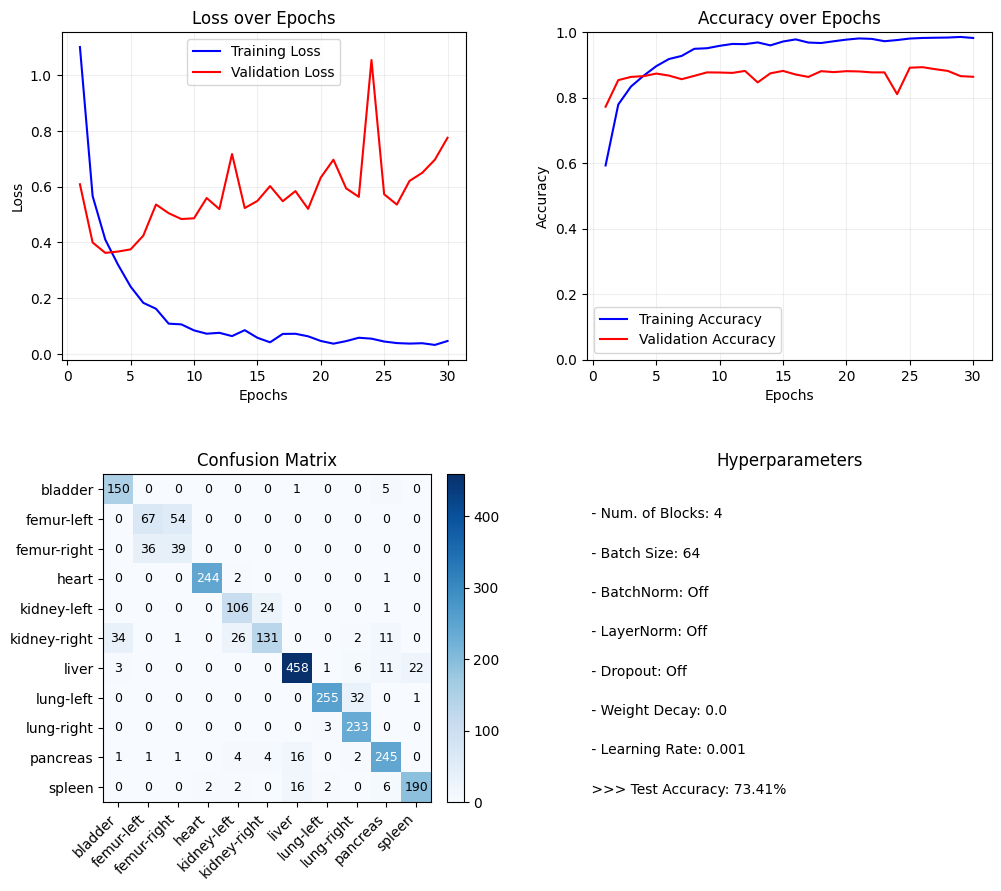

In [56]:
# Visualization
plot_loss_acc_confusion(train_losses_4Blocks, val_losses_4Blocks, train_accuracies_4Blocks, val_accuracies_4Blocks, test_acc_4Blocks,
                          targets, preds, labels_dict, batch_size, learning_rate, num_of_blocks=4)